# Notebook 8 – Optimization Algorithms



## 1. What is Optimization?

Optimization means finding model parameters that make the prediction error as small as possible.

In machine learning, a model has **weights** and sometimes **biases**. During training, the optimizer changes these values so that the loss function decreases.

A simple way to think about it:

**Prediction → Calculate Loss → Find Direction → Update Weights → Repeat**

### Real-world example
Suppose an online store wants to predict whether a transaction is likely to be a high-value order. The model starts with random weights. Optimization gradually adjusts those weights so the predictions become more useful.

### AI/ML usage
Optimization is used while training:
- Linear Regression
- Logistic Regression
- Neural Networks
- Deep Learning models
- Computer Vision models
- NLP models
- Recommendation systems

**My understanding:** The optimizer is the method that tells the model how to move its weights so that the error becomes smaller.


## 2. Gradient Descent

Gradient Descent is the basic optimization idea behind many machine learning algorithms.

The gradient tells us the direction in which the loss increases fastest. Therefore, to reduce the loss, we move in the opposite direction.

### Mathematical intuition

For a weight `w`:

`w_new = w_old - learning_rate × gradient`

The gradient is:

`gradient = dLoss/dw`

The learning rate controls how large the movement is.

### Real-world example
Imagine standing on a hill and trying to reach the lowest point. The slope tells you which direction is uphill, so you move in the opposite direction.

### AI/ML usage
Gradient-based optimization is fundamental to training regression models, classification models and neural networks.

**My understanding:** Gradient Descent does not directly know the best weight. It repeatedly makes small corrections based on the current error.


Weight: 1.898
Bias: 0.367


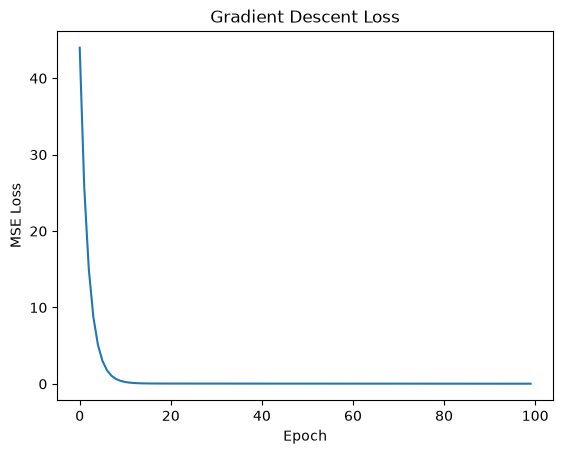

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)

w = 0.0
b = 0.0
learning_rate = 0.01
loss_history = []

for epoch in range(100):
    y_pred = w * x + b
    error = y_pred - y
    loss = np.mean(error ** 2)
    dw = np.mean(2 * error * x)
    db = np.mean(2 * error)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    loss_history.append(loss)

print("Weight:", round(w, 3))
print("Bias:", round(b, 3))

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss")
plt.show()


## 3. Batch Gradient Descent

Batch Gradient Descent uses the **entire training dataset** to calculate the gradient before making one weight update.

### Update idea

`w_new = w_old - η × gradient_using_all_training_samples`

Here `η` is the learning rate.

### Real-world example
If a shop owner wants to decide how to improve a business process, they may study every available transaction before making one decision. That is similar to Batch Gradient Descent.

### Advantages
- Stable gradient direction
- Smooth learning
- Simple to understand

### Limitations
- Can be slow for very large datasets
- Requires more memory
- One update can take a long time

### When to use
It can work well for smaller datasets and problems where stable updates are more important than very fast iteration.

### AI/ML usage
Batch updates are useful when the dataset fits comfortably in memory and stable optimization is desired.


## 4. Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent uses **one training sample at a time** to calculate the gradient and update the weights.

Instead of waiting for all samples:

`one sample → gradient → update`

### Mathematical intuition

`w_new = w_old - η × gradient_of_one_sample`

### Real-world example
Imagine checking one customer transaction at a time and adjusting your prediction rule after every transaction.

### Advantages
- Very frequent updates
- Works well with large datasets
- Can escape some shallow local regions because the updates are noisy

### Limitations
- Loss can fluctuate
- Training can be less stable
- Final convergence may be noisy

### When to use
SGD is useful for large datasets and online or streaming learning.

### AI/ML usage
SGD is widely used for linear models and is also the basic idea behind stochastic training of neural networks.

**Important:** In deep learning, the word SGD often refers to the optimizer that uses mini-batches, even though the original idea is one sample at a time.


## 5. Mini-batch Gradient Descent

Mini-batch Gradient Descent uses a small group of samples for each update.

For example:

`32 samples → gradient → update`

Then the next 32 samples are used.

It is a practical middle ground between Batch Gradient Descent and one-sample SGD.

### Advantages
- Faster than full-batch training
- More stable than one-sample SGD
- Efficient on modern hardware
- Usually a good default for neural networks

### Limitations
- Batch size needs to be selected
- Small batches can be noisy
- Large batches need more memory

### When to use
Mini-batches are commonly used when training neural networks and deep learning models.

### AI/ML usage
CNNs, RNNs, Transformers and many other deep learning models are normally trained using mini-batches.


## 6. Learning Rate

The **learning rate** decides how much the weights change during each update.

`new weight = old weight - learning rate × gradient`

### If the learning rate is too small
- Training becomes slow
- The loss decreases very slowly

### If the learning rate is too large
- Training can overshoot
- Loss may oscillate
- Training may even diverge

### If the learning rate is suitable
- Training usually decreases the loss steadily
- The model can reach a useful solution efficiently

### Real-world example
Walking down a hill:
- Tiny steps = safe but slow
- Huge steps = fast but you may overshoot
- Balanced steps = faster progress with control

### AI/ML usage
Learning rate selection is important in almost every gradient-based machine learning model.


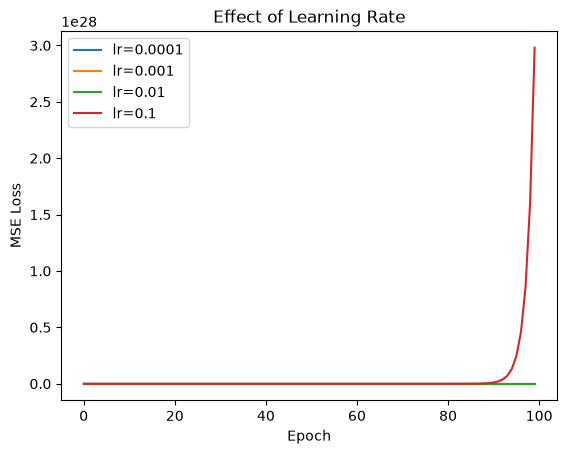

In [2]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    w = 0.0
    b = 0.0
    losses = []
    for epoch in range(100):
        y_pred = w * x + b
        error = y_pred - y
        loss = np.mean(error ** 2)
        dw = np.mean(2 * error * x)
        db = np.mean(2 * error)
        w -= lr * dw
        b -= lr * db
        losses.append(loss)
    results[lr] = losses

for lr, losses in results.items():
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()


## 7. The Dataset

The uploaded file contains online retail transactions.

Important columns for my experiment:
- `Quantity`: number of items in the transaction
- `UnitPrice`: price of one item
- `InvoiceDate`: date and time of the transaction
- `CustomerID`: customer identifier
- `Country`: customer's country

For the optimizer experiment, I will create a simple target called **HighValueOrder**.

A transaction is labelled `1` when its total value is at least the median transaction value, otherwise it is labelled `0`.

I will use:
- Quantity
- UnitPrice
- Hour
- Month

as numerical features.

This gives me a small classification problem that is easy to understand while still using the real dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")

df = df.dropna(subset=["Quantity", "UnitPrice", "InvoiceDate"])
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
threshold = df["TotalAmount"].median()
df["HighValueOrder"] = (df["TotalAmount"] >= threshold).astype(int)
df["Hour"] = df["InvoiceDate"].dt.hour
df["Month"] = df["InvoiceDate"].dt.month

data = df[["Quantity", "UnitPrice", "Hour", "Month", "HighValueOrder"]].sample(20000, random_state=42)

print(data.shape)
print(data.head())
print("High-value threshold:", round(threshold, 2))


(20000, 5)
        Quantity  UnitPrice  Hour  Month  HighValueOrder
269788         2       7.95    11      7               1
83138          4       4.25     9      2               1
538681         3       4.15    14     12               1
58905          1       0.65    16      1               0
388858         6       0.85    15     10               0
High-value threshold: 9.9


## 8. Preparing the Data

Before optimization, I need to put the numerical features on comparable scales.

I will:
1. Separate features and target
2. Split the data into training and testing sets
3. Standardize the features
4. Use a sigmoid function for binary classification

Standardization is important because a feature with a very large numerical scale can dominate the gradient.

The model is:

`z = Xw + b`

and

`prediction = sigmoid(z)`

where:

`sigmoid(z) = 1 / (1 + e^(-z))`


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[["Quantity", "UnitPrice", "Hour", "Month"]].values
y = data["HighValueOrder"].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])


Training samples: 16000
Testing samples: 4000
Number of features: 4


## 9. Logistic Regression Loss and Gradient

For the optimizer experiments, I use a simple Logistic Regression model.

The binary cross-entropy loss is:

`Loss = -mean(y log(p) + (1-y) log(1-p))`

For logistic regression, the gradient can be written as:

`dw = Xᵀ(p-y) / n`

`db = mean(p-y)`

The optimizer changes `w` and `b` using these gradients.

This is a useful example because I can see the effect of different optimization algorithms without hiding the learning process inside a high-level training function.


In [5]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def loss_function(y_true, y_prob):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))

def accuracy_score(y_true, y_prob):
    predictions = (y_prob >= 0.5).astype(int)
    return np.mean(predictions == y_true)


## 10. Batch Gradient Descent on the Retail Dataset

Here I use all training samples for every update.

### Weight update

`w = w - η × dw`

`b = b - η × db`

### What I expect
Because every update sees the whole dataset, the loss curve should usually be smooth.

### When I would use it
For smaller datasets where full-batch computation is affordable and I want stable gradient estimates.


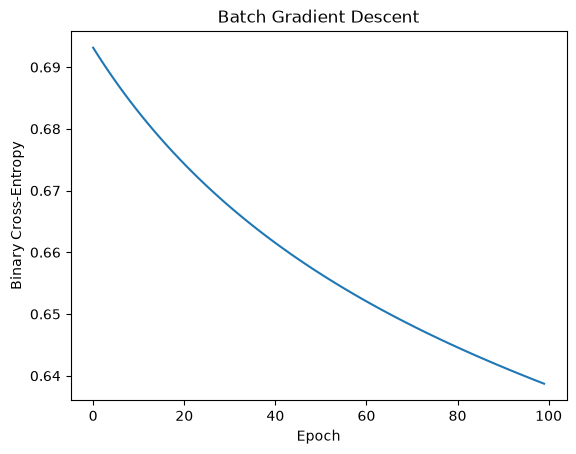

Test accuracy: 0.6432


In [6]:
def batch_gradient_descent(X, y, learning_rate=0.05, epochs=100):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []

    for epoch in range(epochs):
        probabilities = sigmoid(X @ w + b)
        loss = loss_function(y, probabilities)
        error = probabilities - y
        dw = (X.T @ error) / len(X)
        db = np.mean(error)
        w -= learning_rate * dw
        b -= learning_rate * db
        losses.append(loss)

    return w, b, losses

batch_w, batch_b, batch_losses = batch_gradient_descent(X_train, y_train)

plt.plot(batch_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Batch Gradient Descent")
plt.show()

batch_prob = sigmoid(X_test @ batch_w + batch_b)
print("Test accuracy:", round(accuracy_score(y_test, batch_prob), 4))


## 11. Stochastic Gradient Descent

Now I update the weights after every single training example.

### How the weights are updated

For one sample:

`error = prediction - actual`

`w = w - η × error × x`

`b = b - η × error`

### What I expect
The loss curve can be more irregular because every update is based on only one observation.

### Advantage
It can make progress quickly on very large datasets.

### Limitation
The noisy updates can make the training curve fluctuate.


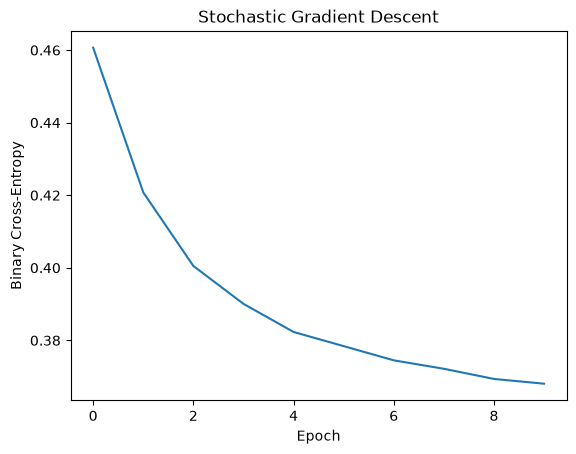

Test accuracy: 0.8635


In [7]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=10):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        order = rng.permutation(len(X))
        for i in order:
            probability = sigmoid(X[i] @ w + b)
            error = probability - y[i]
            w -= learning_rate * error * X[i]
            b -= learning_rate * error
        epoch_prob = sigmoid(X @ w + b)
        losses.append(loss_function(y, epoch_prob))

    return w, b, losses

sgd_w, sgd_b, sgd_losses = stochastic_gradient_descent(X_train, y_train)

plt.plot(sgd_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Stochastic Gradient Descent")
plt.show()

sgd_prob = sigmoid(X_test @ sgd_w + sgd_b)
print("Test accuracy:", round(accuracy_score(y_test, sgd_prob), 4))


## 12. Mini-batch Gradient Descent

Mini-batch training uses a small group of observations per update.

I will use a batch size of 64.

### Weight update

`w = w - η × average_gradient_of_batch`

### My understanding
Mini-batch training gives a useful balance:
- less computation per update than full batch
- less noise than one-sample SGD
- efficient for hardware

This is why mini-batch optimization is extremely common in deep learning.


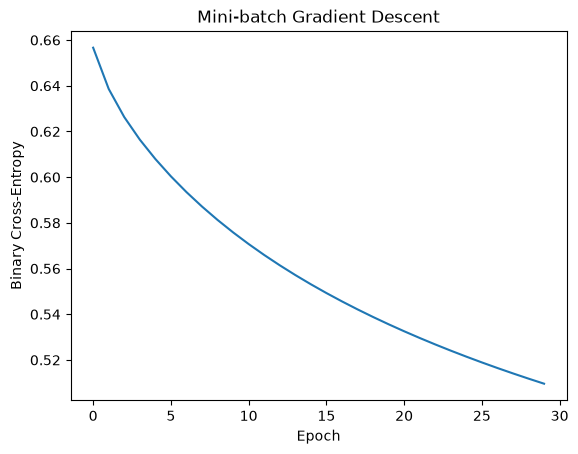

Test accuracy: 0.7982


In [8]:
def mini_batch_gradient_descent(X, y, learning_rate=0.01, epochs=30, batch_size=64):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        order = rng.permutation(len(X))
        X_shuffled = X[order]
        y_shuffled = y[order]

        for start in range(0, len(X), batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            probabilities = sigmoid(X_batch @ w + b)
            error = probabilities - y_batch
            dw = (X_batch.T @ error) / len(X_batch)
            db = np.mean(error)

            w -= learning_rate * dw
            b -= learning_rate * db

        epoch_prob = sigmoid(X @ w + b)
        losses.append(loss_function(y, epoch_prob))

    return w, b, losses

mini_w, mini_b, mini_losses = mini_batch_gradient_descent(X_train, y_train)

plt.plot(mini_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Mini-batch Gradient Descent")
plt.show()

mini_prob = sigmoid(X_test @ mini_w + mini_b)
print("Test accuracy:", round(accuracy_score(y_test, mini_prob), 4))


# 13. Modern Optimizers

The basic SGD update can be improved by keeping some information from previous gradients.

The three optimizers I studied here are:

1. **SGD with Momentum**
2. **RMSprop**
3. **Adam**

All three still use gradients, but they process the gradient information differently.


## 13.1 SGD with Momentum

### Concept

Momentum adds a memory of previous updates.

Instead of only looking at the current gradient, it keeps a running velocity.

### Mathematical intuition

`v = βv + gradient`

`w = w - ηv`

A common value for `β` is `0.9`.

### How it updates weights
If the gradients repeatedly point in a similar direction, the velocity grows and the model moves faster in that direction.

### Real-world example
A ball rolling down a hill gains momentum. It does not completely forget its previous movement at every point.

### Advantages
- Faster movement in consistent directions
- Can reduce zig-zagging
- Often converges faster than plain SGD

### Limitations
- Adds another hyperparameter
- A poorly chosen learning rate can still cause instability

### When to use
Useful when plain SGD is slow or oscillates heavily.

### AI/ML usage
Momentum is commonly used in neural network optimization.


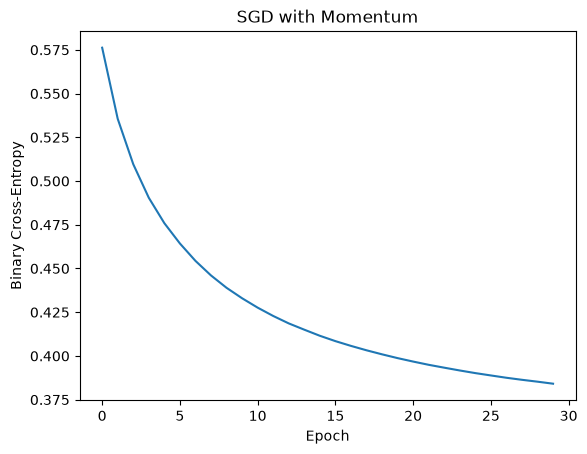

In [9]:
def sgd_momentum(X, y, learning_rate=0.01, beta=0.9, epochs=30, batch_size=64):
    w = np.zeros(X.shape[1])
    b = 0.0
    vw = np.zeros_like(w)
    vb = 0.0
    losses = []
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]
            X_batch = X[idx]
            y_batch = y[idx]
            probabilities = sigmoid(X_batch @ w + b)
            error = probabilities - y_batch
            dw = (X_batch.T @ error) / len(X_batch)
            db = np.mean(error)

            vw = beta * vw + dw
            vb = beta * vb + db
            w -= learning_rate * vw
            b -= learning_rate * vb

        losses.append(loss_function(y, sigmoid(X @ w + b)))

    return w, b, losses

momentum_w, momentum_b, momentum_losses = sgd_momentum(X_train, y_train)

plt.plot(momentum_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("SGD with Momentum")
plt.show()


## 13.2 RMSprop

### Concept

RMSprop keeps a moving average of squared gradients.

This allows the optimizer to use different effective step sizes for different parameters.

### Mathematical intuition

`r = βr + (1-β)gradient²`

`w = w - η × gradient / (sqrt(r) + ε)`

### How it updates weights
If a parameter repeatedly gets large gradients, RMSprop increases its denominator and reduces its effective step size.

### Real-world example
Imagine adjusting several controls where some are extremely sensitive and others are not. RMSprop automatically makes smaller movements for the sensitive controls.

### Advantages
- Adapts the learning rate for each parameter
- Handles uneven gradient sizes
- Often works well for neural networks

### Limitations
- Requires extra memory
- Still depends on hyperparameters
- Can behave differently depending on the problem

### When to use
Useful when gradients have very different scales or when basic SGD struggles.

### AI/ML usage
RMSprop has been used in neural networks, recurrent neural networks and other adaptive optimization settings.


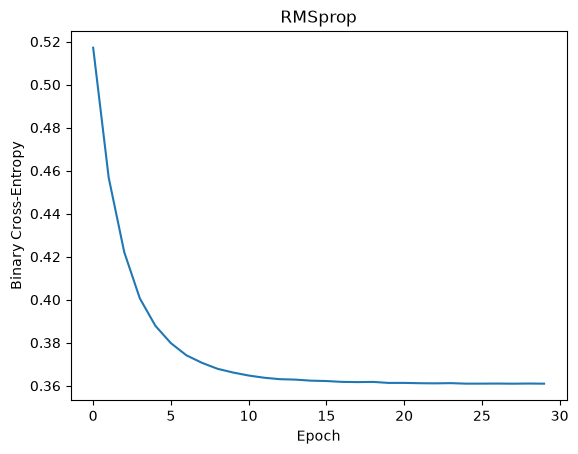

In [10]:
def rmsprop(X, y, learning_rate=0.01, beta=0.9, epsilon=1e-8, epochs=30, batch_size=64):
    w = np.zeros(X.shape[1])
    b = 0.0
    rw = np.zeros_like(w)
    rb = 0.0
    losses = []
    rng = np.random.default_rng(42)

    for epoch in range(epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]
            X_batch = X[idx]
            y_batch = y[idx]
            probabilities = sigmoid(X_batch @ w + b)
            error = probabilities - y_batch
            dw = (X_batch.T @ error) / len(X_batch)
            db = np.mean(error)

            rw = beta * rw + (1 - beta) * (dw ** 2)
            rb = beta * rb + (1 - beta) * (db ** 2)

            w -= learning_rate * dw / (np.sqrt(rw) + epsilon)
            b -= learning_rate * db / (np.sqrt(rb) + epsilon)

        losses.append(loss_function(y, sigmoid(X @ w + b)))

    return w, b, losses

rms_w, rms_b, rms_losses = rmsprop(X_train, y_train)

plt.plot(rms_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("RMSprop")
plt.show()


## 13.3 Adam

Adam means **Adaptive Moment Estimation**.

It combines two useful ideas:
- Momentum-like tracking of the average gradient
- RMSprop-like tracking of squared gradients

### Mathematical intuition

First moment:

`m = β1m + (1-β1)g`

Second moment:

`v = β2v + (1-β2)g²`

Bias correction:

`m̂ = m / (1-β1^t)`

`v̂ = v / (1-β2^t)`

Final update:

`w = w - η × m̂ / (sqrt(v̂) + ε)`

### How it updates weights
Adam remembers both:
- the direction of previous gradients
- the typical size of recent gradients

This gives each parameter an adaptive update.

### Real-world example
A person walking down an uneven hill can use both the direction of previous movement and the steepness of the current area to decide the next step.

### Advantages
- Usually converges quickly
- Adaptive learning rates
- Works well with noisy gradients
- Strong general-purpose optimizer

### Limitations
- Uses more memory than simple SGD
- Can sometimes generalize differently from SGD
- Still needs suitable hyperparameters

### When to use
Adam is often a strong starting point for neural networks and many deep learning experiments.

### AI/ML usage
Adam is widely used in deep learning for NLP, computer vision, generative models and many other neural network tasks.


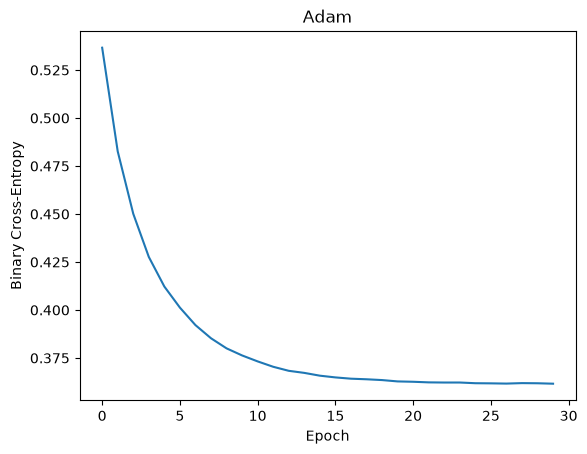

In [11]:
def adam(X, y, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=30, batch_size=64):
    w = np.zeros(X.shape[1])
    b = 0.0
    mw = np.zeros_like(w)
    mb = 0.0
    vw = np.zeros_like(w)
    vb = 0.0
    losses = []
    rng = np.random.default_rng(42)
    step = 0

    for epoch in range(epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            step += 1
            idx = order[start:start + batch_size]
            X_batch = X[idx]
            y_batch = y[idx]
            probabilities = sigmoid(X_batch @ w + b)
            error = probabilities - y_batch
            dw = (X_batch.T @ error) / len(X_batch)
            db = np.mean(error)

            mw = beta1 * mw + (1 - beta1) * dw
            mb = beta1 * mb + (1 - beta1) * db
            vw = beta2 * vw + (1 - beta2) * (dw ** 2)
            vb = beta2 * vb + (1 - beta2) * (db ** 2)

            mw_hat = mw / (1 - beta1 ** step)
            mb_hat = mb / (1 - beta1 ** step)
            vw_hat = vw / (1 - beta2 ** step)
            vb_hat = vb / (1 - beta2 ** step)

            w -= learning_rate * mw_hat / (np.sqrt(vw_hat) + epsilon)
            b -= learning_rate * mb_hat / (np.sqrt(vb_hat) + epsilon)

        losses.append(loss_function(y, sigmoid(X @ w + b)))

    return w, b, losses

adam_w, adam_b, adam_losses = adam(X_train, y_train)

plt.plot(adam_losses)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Adam")
plt.show()


## 14. Comparing the Optimizers

| Optimizer | Main idea | Update behavior | Main advantage | Main limitation |
|---|---|---|---|---|
| SGD | Current gradient | One direction at a time | Simple and memory efficient | Noisy |
| SGD + Momentum | Gradient + velocity | Builds movement from past gradients | Faster and less zig-zagging | Extra hyperparameter |
| RMSprop | Squared-gradient average | Adaptive step size | Handles different gradient scales | Extra memory |
| Adam | Momentum + adaptive scaling | Adaptive and history-aware | Fast practical convergence | More complex |

### My simple way to remember

**SGD:** What is the gradient now?

**Momentum:** What direction have I been moving?

**RMSprop:** How large have recent gradients been?

**Adam:** What direction have I been moving, and how large have the gradients been?


## 15. SGD vs Adam

Both SGD and Adam are gradient-based optimizers, but they treat gradient information differently.

### SGD
SGD generally uses a learning rate and the current gradient.

`w = w - ηg`

It is simple and can work very well when the learning rate schedule is tuned properly.

### Adam
Adam keeps moving averages of the gradient and squared gradient.

`w = w - η × m̂/(sqrt(v̂)+ε)`

It adapts the update for each parameter.

### Practical comparison

| Feature | SGD | Adam |
|---|---|---|
| Simplicity | High | Medium |
| Extra memory | Low | Higher |
| Adaptive step sizes | No | Yes |
| Momentum-like memory | Optional | Built in |
| Common use | Deep learning when carefully tuned | Fast starting point for many deep learning tasks |

### Important observation
A lower training loss for Adam does not automatically mean Adam is always the best choice. Optimizer behavior depends on the dataset, model, learning rate, regularization and generalization performance.


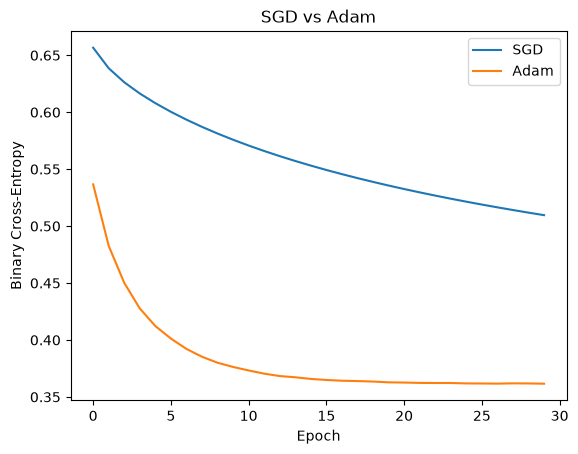

SGD test accuracy: 0.7982
Adam test accuracy: 0.8672


In [12]:
sgd_w, sgd_b, sgd_losses = mini_batch_gradient_descent(
    X_train, y_train, learning_rate=0.01, epochs=30, batch_size=64
)

adam_w, adam_b, adam_losses = adam(
    X_train, y_train, learning_rate=0.01, epochs=30, batch_size=64
)

plt.plot(sgd_losses, label="SGD")
plt.plot(adam_losses, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("SGD vs Adam")
plt.legend()
plt.show()

sgd_test_prob = sigmoid(X_test @ sgd_w + sgd_b)
adam_test_prob = sigmoid(X_test @ adam_w + adam_b)

print("SGD test accuracy:", round(accuracy_score(y_test, sgd_test_prob), 4))
print("Adam test accuracy:", round(accuracy_score(y_test, adam_test_prob), 4))


## 16. Learning Rate Experiment on the Same Dataset

Now I will deliberately change the learning rate.

I want to observe three possible situations:

- **Small learning rate:** slower learning
- **Reasonable learning rate:** steady improvement
- **Large learning rate:** unstable or very fast changes

The exact best value depends on the model and dataset, so the experiment is more useful than memorizing one universal learning rate.


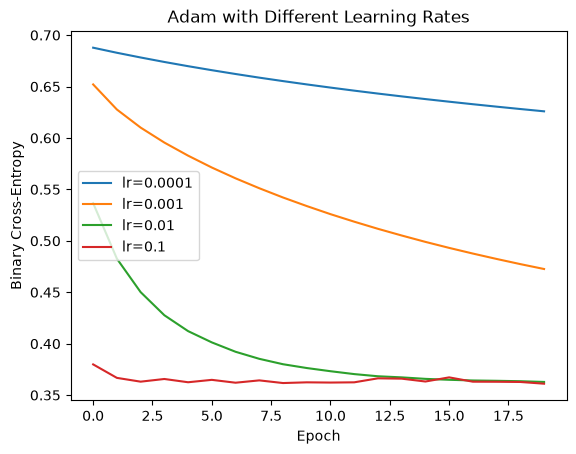

Learning rate: 0.0001 Final loss: 0.6259
Learning rate: 0.001 Final loss: 0.4726
Learning rate: 0.01 Final loss: 0.3628
Learning rate: 0.1 Final loss: 0.3611


In [13]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates:
    _, _, losses = adam(
        X_train, y_train, learning_rate=lr, epochs=20, batch_size=64
    )
    lr_results[lr] = losses

for lr, losses in lr_results.items():
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Adam with Different Learning Rates")
plt.legend()
plt.show()

for lr, losses in lr_results.items():
    print("Learning rate:", lr, "Final loss:", round(losses[-1], 4))
